In [8]:
### IMPORTS 
import mne
import matplotlib.pyplot as plt
import numpy as np

import os
import pandas as pd
import seaborn as sns 
from mne.preprocessing import ICA
from mne_icalabel import label_components
from autoreject import AutoReject
from scipy.signal.windows import hamming
import statsmodels.formula.api as smf
from autoreject import get_rejection_threshold
import gc
from specparam import SpectralGroupModel
from specparam import SpectralModel
#from specparam.analysis import get_band_peak_group
from mne.preprocessing import create_eog_epochs, create_ecg_epochs
from scipy.io import loadmat
import scipy.stats as stats
from scipy.stats import ttest_1samp, wilcoxon
from pathlib import Path
import time
import warnings

from scipy.signal import welch
warnings.filterwarnings("ignore", category=DeprecationWarning)
#%matplotlib qt
%matplotlib widget

In [3]:
## FUNCTIONZ

def compute_stage_psds(
    data,
    sfreq,
    epoch_labels,
    window_sec=05.0,
    overlap=0.5,
    freq_range=(1, 45),
):
    """
    Estimate PSD per sleep stage using Welch's method.

    Parameters
    ----------
    data : ndarray, shape (n_channels, n_samples)
        Continuous EEG/iEEG signal.
    sfreq : float
        Sampling frequency in Hz.
    epoch_labels : list of (start_sample, end_sample, stage_str)
        Epoch boundaries and their sleep stage labels.
    window_sec : float
        Welch window length in seconds (default 15 s).
    overlap : float
        Fractional overlap between windows (default 0.5 = 50%).
    freq_range : tuple of (float, float)
        Frequency band to retain in output.

    Returns
    -------
    freqs : ndarray, shape (n_freqs,)
    stage_psds : dict  {stage_str: ndarray (n_channels, n_freqs)}
        Mean PSD per stage, averaged over all epochs of that stage.
    """
    nperseg = int(window_sec * sfreq)
    noverlap = int(nperseg * overlap)

    stage_accum = {}  # stage -> list of per-epoch mean PSDs

    for start, end, stage in epoch_labels:
        segment = data[:, start:end]
        if segment.shape[1] < nperseg:
            continue

        freqs, psd = welch(
            segment,
            fs=sfreq,
            window="hamming",
            nperseg=nperseg,
            noverlap=noverlap,
            axis=-1,
        )

        # Restrict to requested frequency range
        mask = (freqs >= freq_range[0]) & (freqs <= freq_range[1])
        freqs_out = freqs[mask]
        psd_out = psd[:, mask]

        # Mean over Welch sub-windows (welch already returns a single PSD per
        # channel; here we collect per-epoch means to average later)
        stage_accum.setdefault(stage, []).append(psd_out)

    stage_psds = {
        stage: np.mean(np.stack(epochs, axis=0), axis=0)  # (n_channels, n_freqs)
        for stage, epochs in stage_accum.items()
    }
    return freqs_out, stage_psds



In [6]:
## SETUP

#load in data and annotations 
subj_id = "0001" 
psg_path = "/Users/elizabethkaplan/Desktop/MASS_PSG/01-02-0001 PSG.edf" 
annotation_file_path = "/Users/elizabethkaplan/Desktop/SS2_Data/01-02-0001 KComplexes_E1.edf" 
spindles_annotations = "/Users/elizabethkaplan/Desktop/SS2_Data/01-02-0001 Spindles_E1.edf" 
staging_file_path = '/Users/elizabethkaplan/Desktop/SS2_Data/01-02-0001-Base.edf' 

# preload=True loads the data into memory, enabling faster operations

raw = mne.io.read_raw_edf(psg_path, preload=True) 
annot = mne.read_annotations(annotation_file_path) 
spindles = mne.read_annotations(spindles_annotations) 
stages = mne.read_annotations(staging_file_path)

sfreq = raw.info["sfreq"]

#ch c3
c3_idx = [i for i, ch in enumerate(raw.ch_names) if "C3" in ch.upper()]
if not c3_idx:
    raise ValueError(f"No C3 channel found. Available: {raw.ch_names}")
c3_data = raw.get_data(picks=c3_idx)

# build sleep stages based on 'Base' edf file 
# stages.onset is relative to the raw recording start (seconds)
epoch_labels = []
for ann in stages:
    stage_label = ann["description"].strip()   # e.g. "Sleep stage N2"
    start_samp  = int(ann["onset"]    * sfreq)
    stop_samp   = int((ann["onset"] + ann["duration"]) * sfreq)
    stop_samp   = min(stop_samp, c3_data.shape[1])   # clip to recording end
    if stop_samp > start_samp:
        epoch_labels.append((start_samp, stop_samp, stage_label))

#from collections import Counter
#counts = Counter(lbl for _, _, lbl in epoch_labels)
#for stage, n in sorted(counts.items()):
#    print(f"  {stage}: {n} epochs")

Extracting EDF parameters from /Users/elizabethkaplan/Desktop/MASS_PSG/01-02-0001 PSG.edf...
EDF file detected
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 7412735  =      0.000 ... 28955.996 secs...
<Annotations | 1419 segments: Sleep stage 1 (77), Sleep stage 2 (745), ...>


In [9]:
# ── Run Welch PSD per stage ─────────────────────────────────────────────────
freqs, stage_psds = compute_stage_psds(
    c3_data,
    sfreq,
    epoch_labels,
    window_sec=15.0,
    overlap=0.5,
    freq_range=(1, 45),
)

print(f"\nFrequency axis: {freqs[0]:.2f} – {freqs[-1]:.2f} Hz  ({len(freqs)} bins)")
for stage, psd in stage_psds.items():
    print(f"  {stage}: PSD shape {psd.shape}")

C3 channel: EEG C3-CLE, sfreq: 256.0 Hz, duration: 28956.0 s

1419 staging epochs found:
  Sleep stage 1: 77 epochs
  Sleep stage 2: 745 epochs
  Sleep stage 3: 105 epochs
  Sleep stage 4: 170 epochs
  Sleep stage ?: 33 epochs
  Sleep stage R: 242 epochs
  Sleep stage W: 47 epochs

Frequency axis: 1.00 – 45.00 Hz  (661 bins)
  Sleep stage ?: PSD shape (1, 661)
  Sleep stage W: PSD shape (1, 661)
  Sleep stage 1: PSD shape (1, 661)
  Sleep stage 2: PSD shape (1, 661)
  Sleep stage 3: PSD shape (1, 661)
  Sleep stage 4: PSD shape (1, 661)
  Sleep stage R: PSD shape (1, 661)


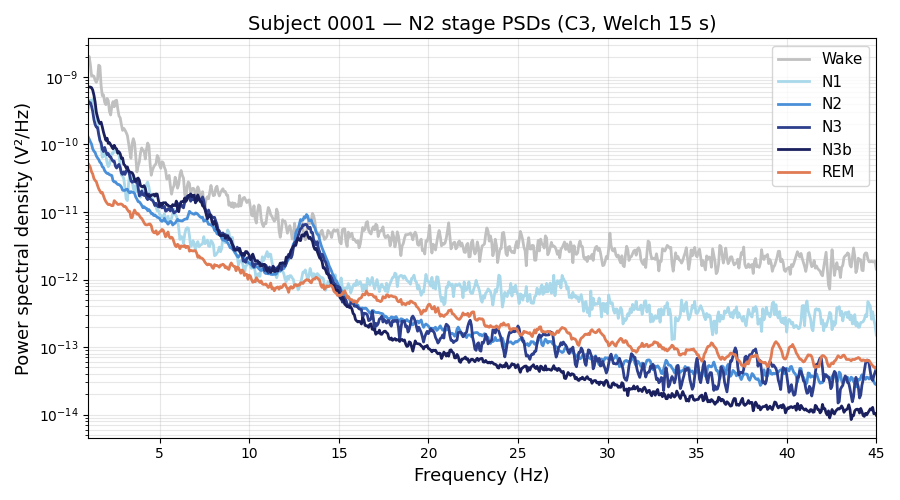

In [10]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np

# ── Stage display settings ──────────────────────────────────────────────────
stage_map = {
    "Sleep stage W": ("Wake",  "silver"),
    "Sleep stage 1": ("N1",    "#a8d8ea"),
    "Sleep stage 2": ("N2",    "#4a90d9"),
    "Sleep stage 3": ("N3",    "#2c3e8c"),
    "Sleep stage 4": ("N3b",   "#1a1f5e"),   # or merge with stage 3
    "Sleep stage R": ("REM",   "#e07b54"),
    "Sleep stage ?": None,                   # exclude unknowns
}

fig, ax = plt.subplots(figsize=(9, 5))

for raw_label, psd in stage_psds.items():
    if stage_map.get(raw_label) is None:
        continue                              # skip "?"
    display_name, color = stage_map[raw_label]
    ax.semilogy(freqs, psd[0], label=display_name, color=color, linewidth=2)

ax.set_xlabel("Frequency (Hz)", fontsize=13)
ax.set_ylabel("Power spectral density (V²/Hz)", fontsize=13)
ax.set_title(f"Subject {subj_id} — N2 stage PSDs (C3, Welch 15 s)", fontsize=14)
ax.set_xlim(1, 45)
ax.legend(fontsize=11, framealpha=0.8)
ax.grid(True, which="both", alpha=0.3)

plt.tight_layout()
plt.show()

In [13]:
## CELL — Whole-night sliding-window spectrogram

from scipy.signal import welch
import numpy as np

# ── Parameters ──────────────────────────────────────────────────────────────
win_sec   = 10.0          # analysis window length (s)
step_sec  = 5.0           # step between windows (s)
fmin, fmax = 1.0, 45.0   # frequency range to keep

nperseg  = int(win_sec * sfreq)
step_smp = int(step_sec * sfreq)
n_samp   = c3_data.shape[1]

# sliding window start samples
starts = np.arange(0, n_samp - nperseg, step_smp)

# ── Compute PSD at each window ───────────────────────────────────────────────
psd_list  = []
t_centres = []

for s in starts:
    seg = c3_data[0, s:s + nperseg].astype(float)
    freqs_w, p = welch(seg, fs=sfreq, window="hamming",
                       nperseg=nperseg, noverlap=nperseg // 2)
    if s == starts[0]:                        # grab freq axis once
        fmask = (freqs_w >= fmin) & (freqs_w <= fmax)
        freqs_tf = freqs_w[fmask]
    psd_list.append(p[fmask])
    t_centres.append((s + nperseg / 2) / sfreq)   # centre time in seconds

tfr      = np.array(psd_list)     # (n_times, n_freqs)
t_hours  = np.array(t_centres) / 3600.0

print(f"TFR shape: {tfr.shape}  ({tfr.shape[0]} windows × {tfr.shape[1]} freq bins)")
print(f"Time range: {t_hours[0]:.3f} – {t_hours[-1]:.3f} h")
print(f"Freq range: {freqs_tf[0]:.2f} – {freqs_tf[-1]:.2f} Hz")

TFR shape: (5790, 441)  (5790 windows × 441 freq bins)
Time range: 0.001 – 8.042 h
Freq range: 1.00 – 45.00 Hz


In [14]:
## CELL — Label each window with its sleep stage (for hypnogram overlay)

# Build a lookup: for each window centre time, find which staging epoch it falls in
stage_order = {"Sleep stage W": 0, "Sleep stage 1": 1, "Sleep stage 2": 2,
               "Sleep stage 3": 3, "Sleep stage 4": 3,   # merge 3+4 → N3
               "Sleep stage R": 4, "Sleep stage ?": np.nan}

window_stages = []
for t in t_centres:
    label = "Sleep stage ?"
    for ann in stages:
        if ann["onset"] <= t < ann["onset"] + ann["duration"]:
            label = ann["description"].strip()
            break
    window_stages.append(label)

stage_numeric = np.array([stage_order.get(s, np.nan) for s in window_stages])

print("Stage counts across windows:")
from collections import Counter
for k, v in sorted(Counter(window_stages).items()):
    print(f"  {k}: {v}")

Stage counts across windows:
  Sleep stage 1: 308
  Sleep stage 2: 2980
  Sleep stage 3: 420
  Sleep stage 4: 680
  Sleep stage ?: 246
  Sleep stage R: 968
  Sleep stage W: 188


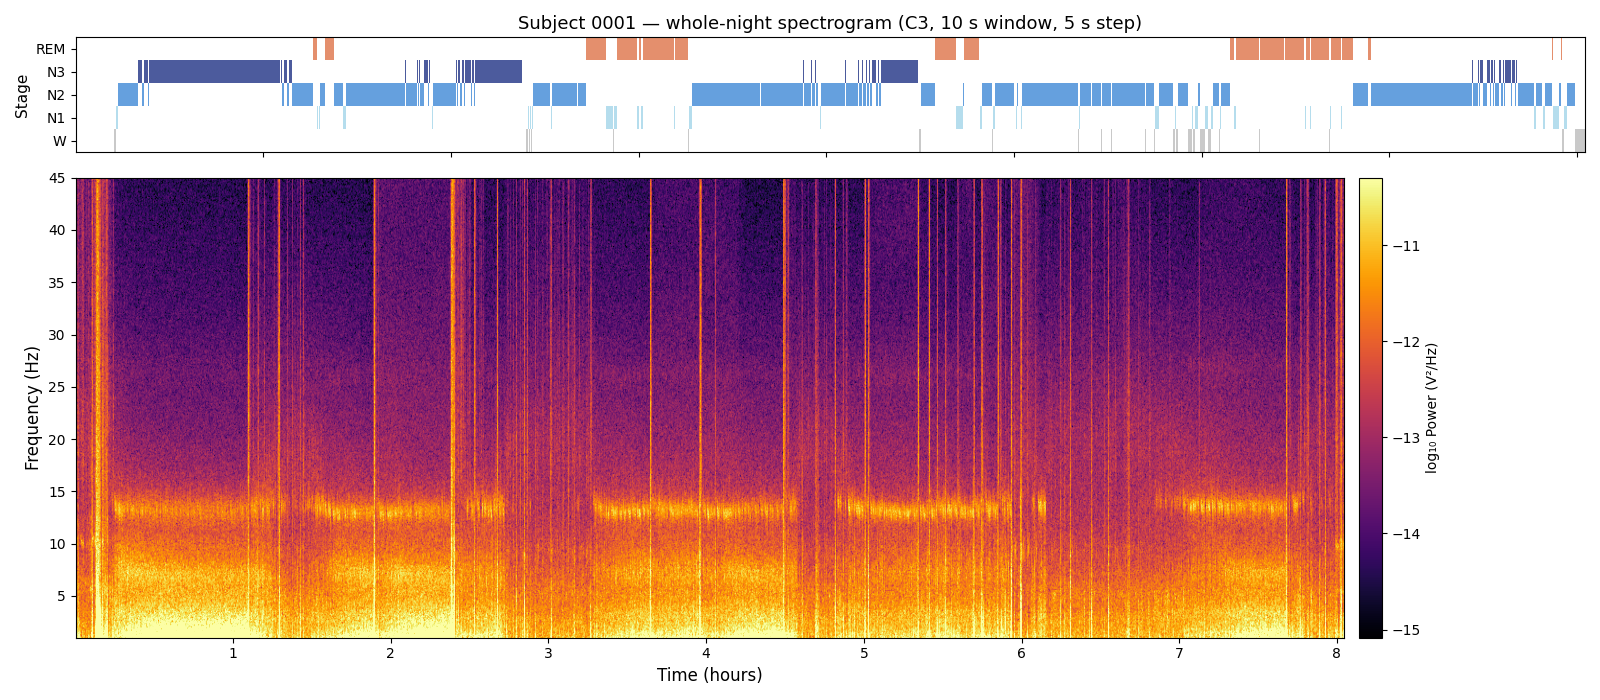

In [15]:
## CELL — Plot spectrogram + hypnogram

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

fig, (ax_hyp, ax_tf) = plt.subplots(
    2, 1, figsize=(16, 7),
    gridspec_kw={"height_ratios": [1, 4]},
    sharex=True,
)

# ── Hypnogram ────────────────────────────────────────────────────────────────
stage_labels = {0: "W", 1: "N1", 2: "N2", 3: "N3", 4: "REM"}
stage_colors = {0: "silver", 1: "#a8d8ea", 2: "#4a90d9", 3: "#2c3e8c", 4: "#e07b54"}

for i in range(len(t_hours) - 1):
    sv = stage_numeric[i]
    if np.isnan(sv):
        continue
    ax_hyp.fill_between(
        [t_hours[i], t_hours[i+1]], [sv, sv], [sv + 1, sv + 1],
        color=stage_colors.get(int(sv), "white"), alpha=0.85, linewidth=0,
    )

ax_hyp.set_yticks([0.5, 1.5, 2.5, 3.5, 4.5])
ax_hyp.set_yticklabels(["W", "N1", "N2", "N3", "REM"], fontsize=10)
ax_hyp.set_ylim(0, 5)
ax_hyp.set_ylabel("Stage", fontsize=11)
ax_hyp.set_title(f"Subject {subj_id} — whole-night spectrogram (C3, {win_sec:.0f} s window, {step_sec:.0f} s step)", fontsize=13)

# ── Spectrogram ──────────────────────────────────────────────────────────────
# log-scale power, clip extreme values for contrast
log_tfr = np.log10(tfr.T + 1e-30)
vmin, vmax = np.percentile(log_tfr, [2, 98])

im = ax_tf.imshow(
    log_tfr,
    aspect="auto",
    origin="lower",
    extent=[t_hours[0], t_hours[-1], freqs_tf[0], freqs_tf[-1]],
    cmap="inferno",
    vmin=vmin, vmax=vmax,
)

ax_tf.set_ylabel("Frequency (Hz)", fontsize=12)
ax_tf.set_xlabel("Time (hours)", fontsize=12)

cbar = plt.colorbar(im, ax=ax_tf, pad=0.01)
cbar.set_label("log₁₀ Power (V²/Hz)", fontsize=10)

plt.tight_layout()
plt.show()

In [ ]:
## CELL — Fit aperiodic params at every 10s window (time-resolved)

try:
    from specparam import SpectralGroupModel
except ImportError:
    from fooof import FOOOFGroup as SpectralGroupModel

# ── Fit specparam on all windows at once ────────────────────────────────────
fg = SpectralGroupModel(
    peak_width_limits=[1, 12],
    max_n_peaks=8,
    min_peak_height=0.0,
    peak_threshold=2.0,
    aperiodic_mode="fixed",
    verbose=False,
)

# tfr is (n_times, n_freqs) in linear power — specparam expects log10 power
fg.fit(freqs_tf, np.clip(tfr, 1e-30, None), freq_range=[1, 45])

# ── Extract parameters ───────────────────────────────────────────────────────
exponent = fg.get_params("aperiodic", "exponent")
offset   = fg.get_params("aperiodic", "offset")
r2       = fg.get_params("r_squared")

print(f"Fitted {len(exponent)} windows")
print(f"Exponent: mean={np.nanmean(exponent):.3f}, std={np.nanstd(exponent):.3f}")
print(f"Offset:   mean={np.nanmean(offset):.3f},   std={np.nanstd(offset):.3f}")
print(f"R²:       mean={np.nanmean(r2):.3f},       min={np.nanmin(r2):.3f}")

In [20]:
## CELL — Time-resolved aperiodic using your compute_aperiodic_params

from tqdm import tqdm  # pip install tqdm if needed, or remove and use print

nperseg  = int(win_sec * sfreq)
step_smp = int(step_sec * sfreq)
n_samp   = c3_data.shape[1]
starts   = np.arange(0, n_samp - nperseg, step_smp)

exponent   = []
offset     = []
t_centres  = []

for s in tqdm(starts, desc="Fitting aperiodic"):
    seg = c3_data[0, s:s + nperseg].astype(float)
    try:
        off, exp = compute_aperiodic_params(seg, sfreq, psd_settings)
        offset.append(off)
        exponent.append(exp)
    except Exception:
        offset.append(np.nan)
        exponent.append(np.nan)
    t_centres.append((s + nperseg / 2) / sfreq)

exponent  = np.array(exponent)
offset    = np.array(offset)
t_hours   = np.array(t_centres) / 3600.0

print(f"Done. {len(exponent)} windows")
print(f"Exponent: mean={np.nanmean(exponent):.3f}, std={np.nanstd(exponent):.3f}")
print(f"Offset:   mean={np.nanmean(offset):.3f},   std={np.nanstd(offset):.3f}")

Fitting aperiodic: 100%|█████████████████| 5790/5790 [00:00<00:00, 26425.54it/s]

Done. 5790 windows
Exponent: mean=nan, std=nan
Offset:   mean=nan,   std=nan



/var/folders/s6/21s_2dfj2f195fl1lglp7jrw0000gn/T/ipykernel_3022/4069853189.py:30: RuntimeWarning: Mean of empty slice
  print(f"Exponent: mean={np.nanmean(exponent):.3f}, std={np.nanstd(exponent):.3f}")
/Users/elizabethkaplan/opt/anaconda3/lib/python3.9/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/var/folders/s6/21s_2dfj2f195fl1lglp7jrw0000gn/T/ipykernel_3022/4069853189.py:31: RuntimeWarning: Mean of empty slice
  print(f"Offset:   mean={np.nanmean(offset):.3f},   std={np.nanstd(offset):.3f}")
